In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')

In [3]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
759,1,1,female,33.000000,0,0,86.5,S
253,0,3,male,30.000000,1,0,16.1,S
191,0,2,male,19.000000,0,0,13.0,S
602,0,1,male,29.699118,0,0,42.4,S


In [4]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

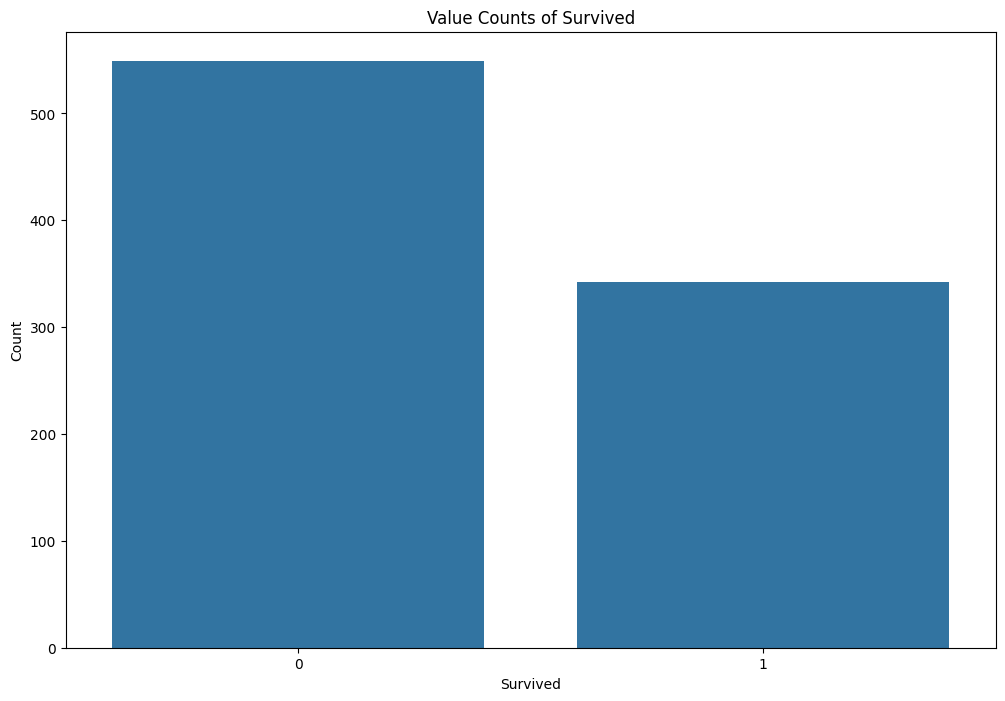

In [5]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

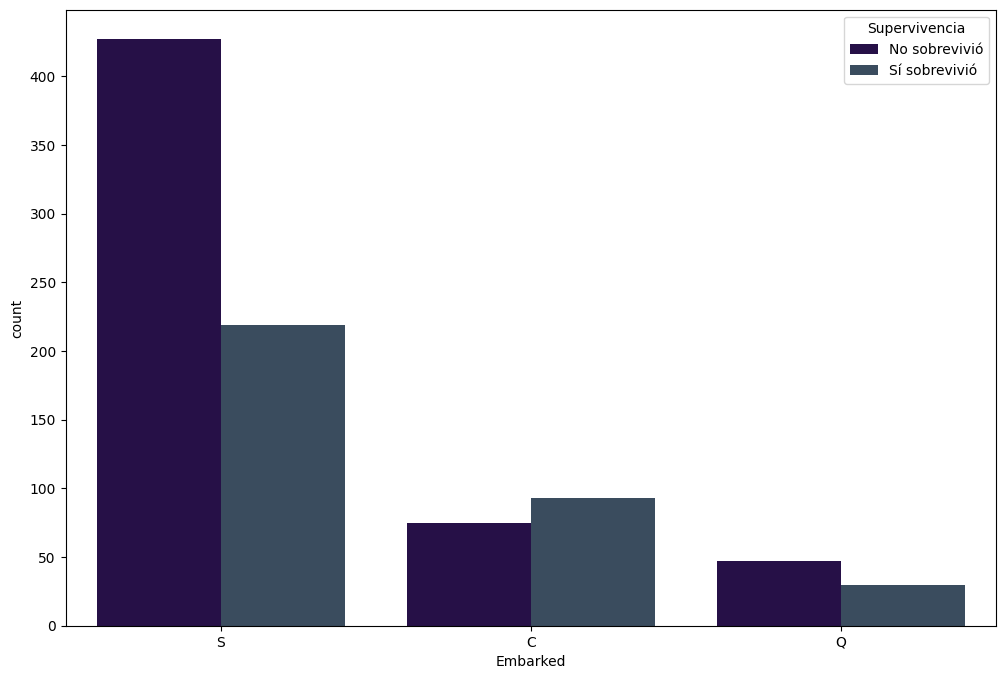

In [6]:
plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Embarked', hue = 'Survived', palette=color) 
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

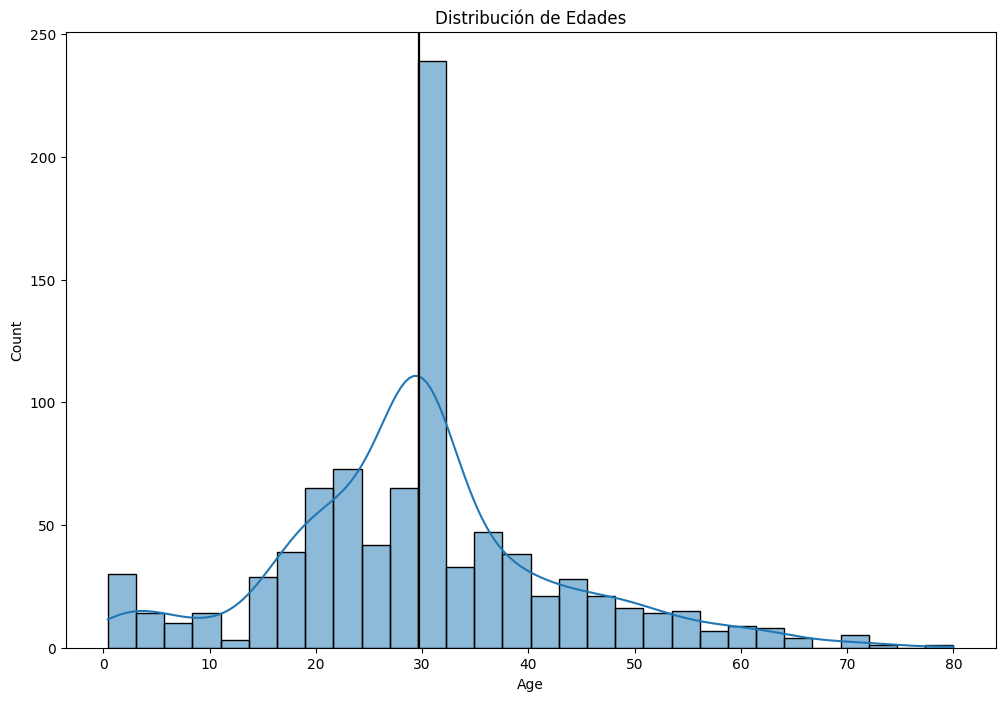

Media: 29.69911764705882
Mediana: 29.69911764705882
Moda: 29.69911764705882


In [7]:
plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

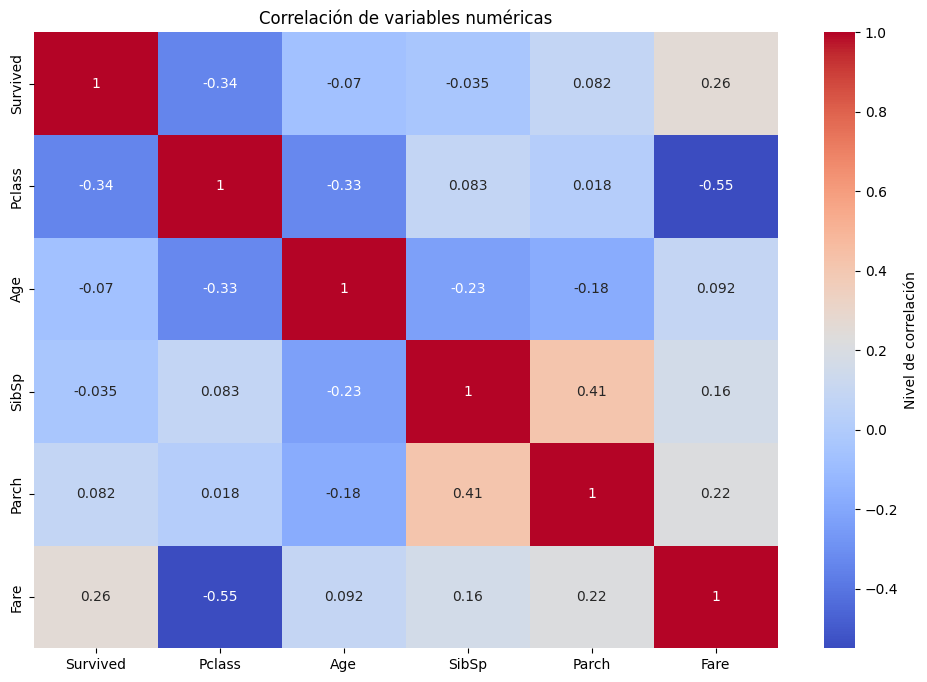

In [8]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

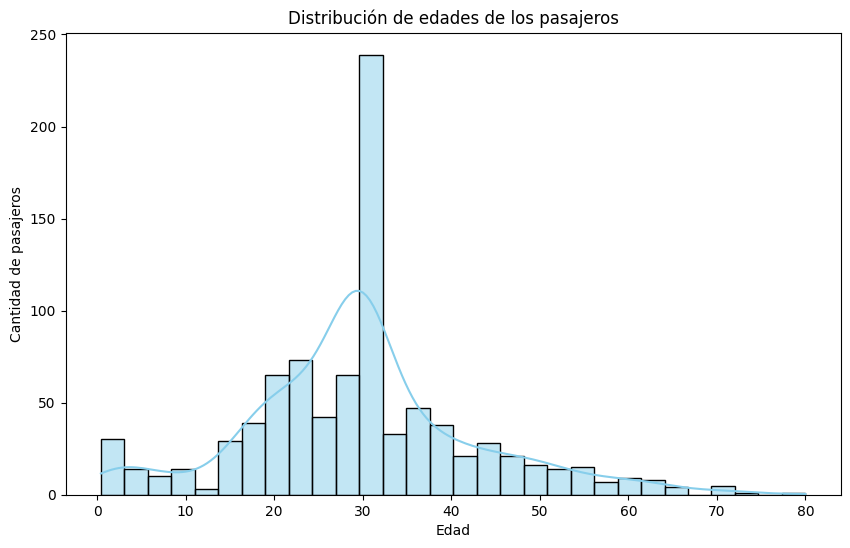

In [9]:
# 1: Distribución de edades de los pasajeros
plt.figure(figsize=(10,6))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Distribución de edades de los pasajeros')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pasajeros')
plt.show()

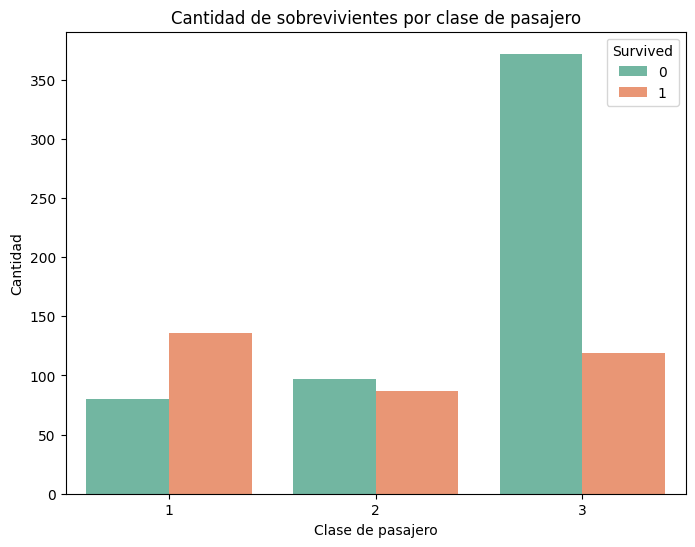

In [10]:
#  2: Cantidad de sobrevivientes por clase de pasajero (Pclass)
plt.figure(figsize=(8,6))
sns.countplot(x='Pclass', hue='Survived', data=df, palette='Set2')
plt.title('Cantidad de sobrevivientes por clase de pasajero')
plt.xlabel('Clase de pasajero')
plt.ylabel('Cantidad')
plt.show()

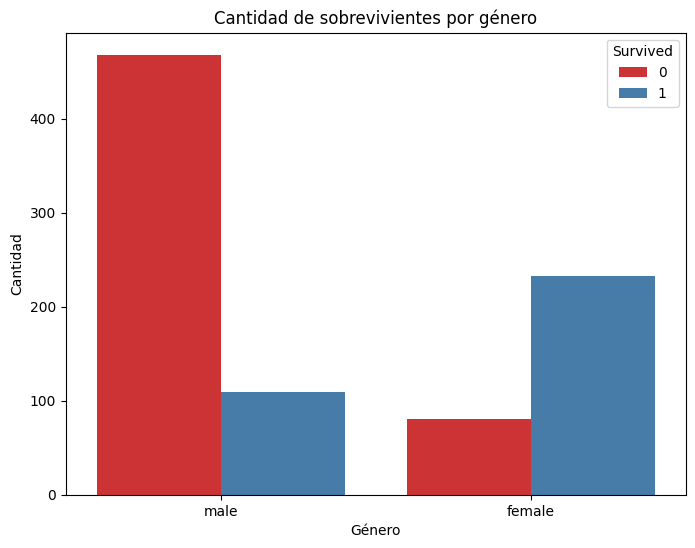

In [11]:
#3: Cantidad de sobrevivientes por género (Sex)
plt.figure(figsize=(8,6))
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set1')
plt.title('Cantidad de sobrevivientes por género')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.show()

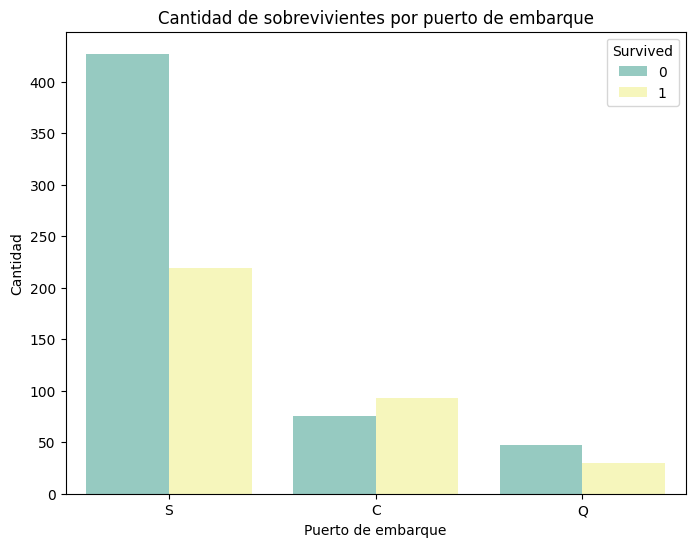

In [12]:
#  4: Cantidad de sobrevivientes por puerto de embarque (Embarked)
plt.figure(figsize=(8,6))
sns.countplot(x='Embarked', hue='Survived', data=df, palette='Set3')
plt.title('Cantidad de sobrevivientes por puerto de embarque')
plt.xlabel('Puerto de embarque')
plt.ylabel('Cantidad')
plt.show()

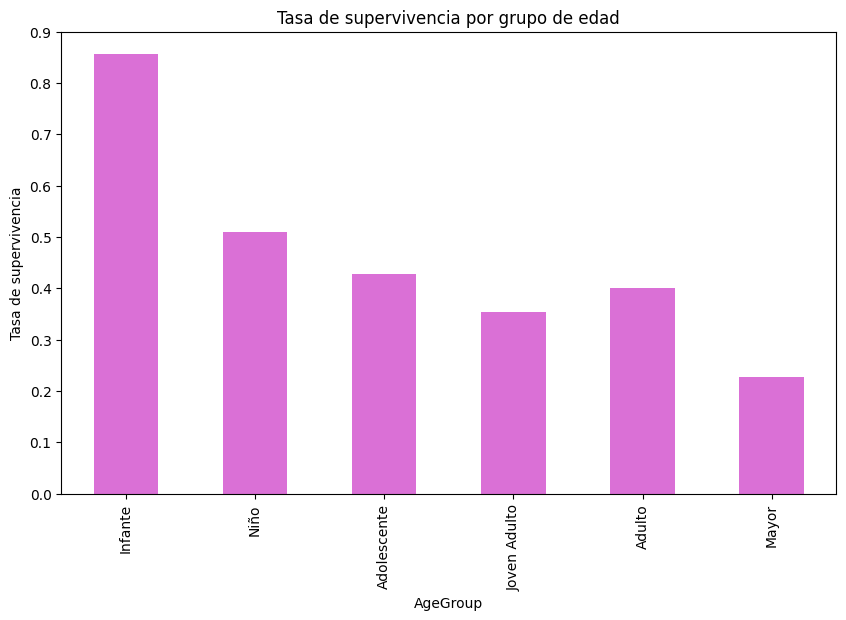

In [13]:
#  5: Agrupar edades y mostrar tasa de supervivencia por grupo de edad
bins = [0, 1, 12, 18, 35, 60, 120]
labels = ['Infante', 'Niño', 'Adolescente', 'Joven Adulto', 'Adulto', 'Mayor']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_survival = df.groupby('AgeGroup')['Survived'].mean()

plt.figure(figsize=(10,6))
age_survival.plot(kind='bar', color='orchid')
plt.title('Tasa de supervivencia por grupo de edad')
plt.ylabel('Tasa de supervivencia')
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_9684\3614142206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=df, palette='pastel')


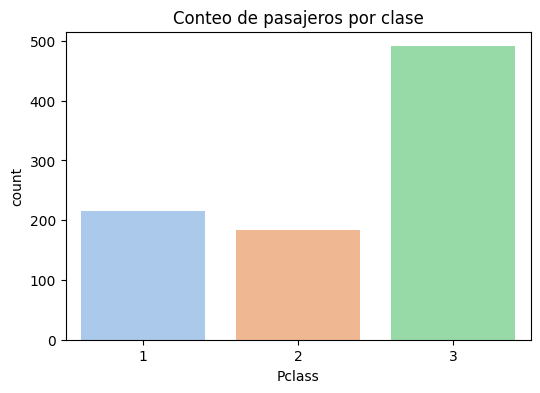

In [14]:
#  6: Conteo de pasajeros en cada clase (Pclass)
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', data=df, palette='pastel')
plt.title('Conteo de pasajeros por clase')
plt.show()

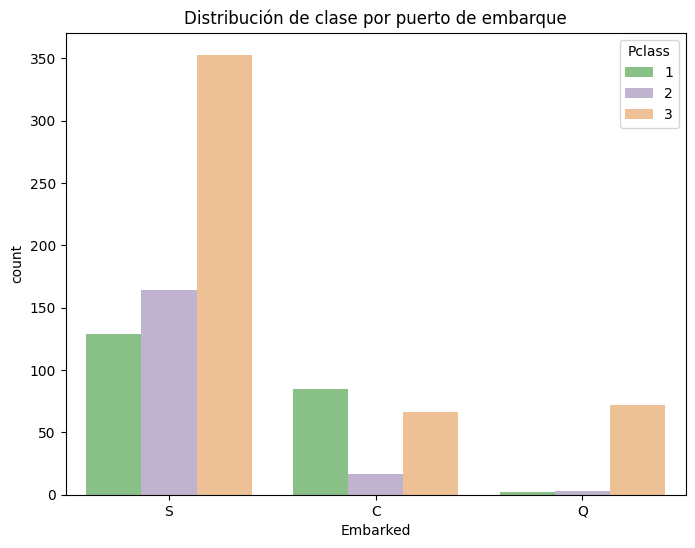

In [15]:
#  8: Distribución de clase de pasajero por puerto de embarque (Embarked)
plt.figure(figsize=(8,6))
sns.countplot(x='Embarked', hue='Pclass', data=df, palette='Accent')
plt.title('Distribución de clase por puerto de embarque')
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_9684\1844758782.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='Set2')


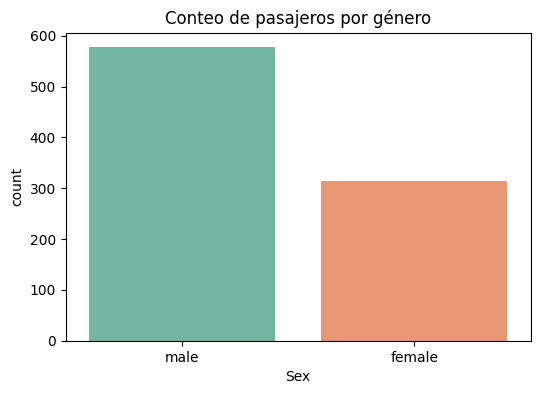

In [16]:
# 9: Conteo de pasajeros por género (Sex)
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df, palette='Set2')
plt.title('Conteo de pasajeros por género')
plt.show()

In [17]:
#  10: Valores máximo y mínimo de la columna de edad
print("Edad máxima:", df['Age'].max())
print("Edad mínima:", df['Age'].min())

Edad máxima: 80.0
Edad mínima: 0.42


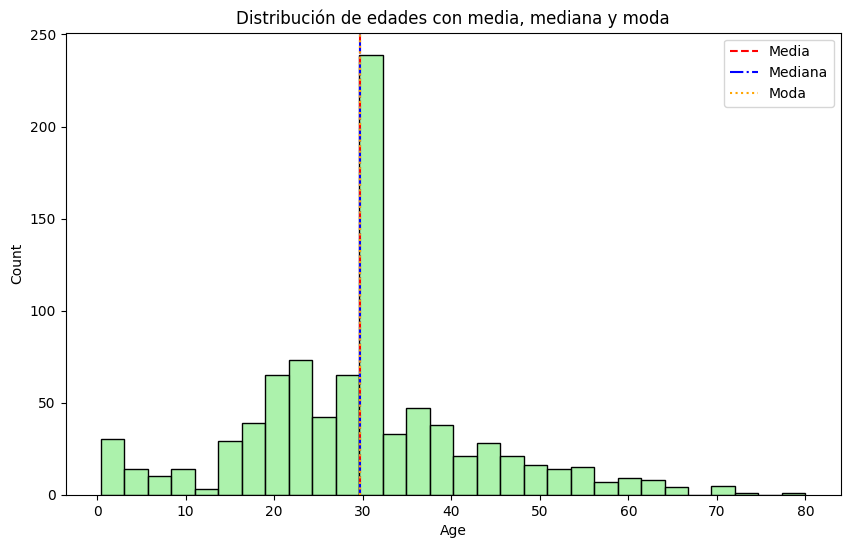

In [18]:
#  11: Distribución de edades con media, mediana y moda
plt.figure(figsize=(10,6))
sns.histplot(df['Age'].dropna(), bins=30, kde=False, color='lightgreen')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Media')
plt.axvline(df['Age'].median(), color='blue', linestyle='-.', label='Mediana')
plt.axvline(df['Age'].mode()[0], color='orange', linestyle=':', label='Moda')
plt.title('Distribución de edades con media, mediana y moda')
plt.legend()
plt.show()

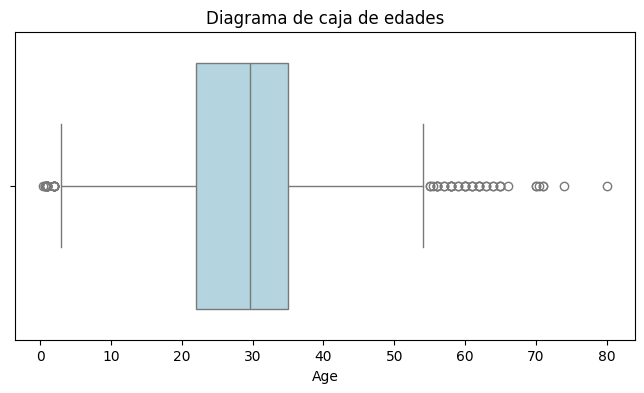

In [19]:
#  12: Diagrama de caja (boxplot) para edades
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Age'], color='lightblue')
plt.title('Diagrama de caja de edades')
plt.show()

In [20]:
# 13: Valores máximo y mínimo de tarifa (Fare)
print("Tarifa máxima:", df['Fare'].max())
print("Tarifa mínima:", df['Fare'].min())

Tarifa máxima: 512.3292
Tarifa mínima: 0.0


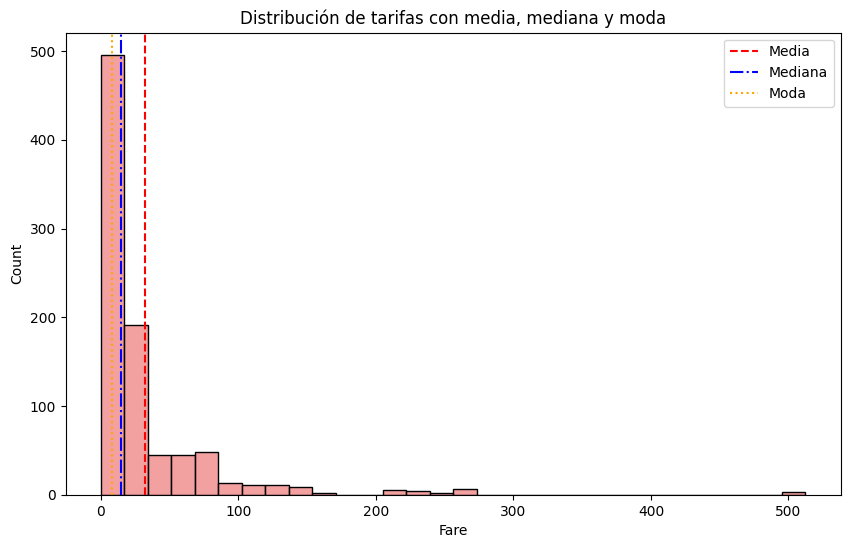

In [21]:
#  14: Distribución de tarifas con media, mediana y moda
plt.figure(figsize=(10,6))
sns.histplot(df['Fare'].dropna(), bins=30, kde=False, color='lightcoral')
plt.axvline(df['Fare'].mean(), color='red', linestyle='--', label='Media')
plt.axvline(df['Fare'].median(), color='blue', linestyle='-.', label='Mediana')
plt.axvline(df['Fare'].mode()[0], color='orange', linestyle=':', label='Moda')
plt.title('Distribución de tarifas con media, mediana y moda')
plt.legend()
plt.show()

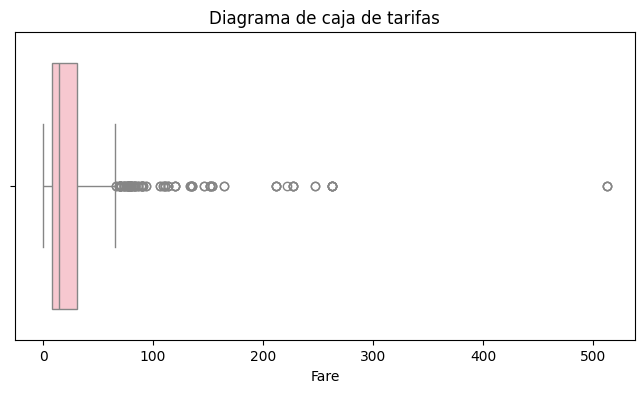

In [22]:
#  15: Diagrama de caja (boxplot) para tarifas
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Fare'], color='pink')
plt.title('Diagrama de caja de tarifas')
plt.show()

In [23]:
# 16: Pasajeros que pagaron 0 en tarifa
df_zero_fare = df[df['Fare'] == 0]
df_zero_fare

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup
179,0,3,male,36.000000,0,0,0.0,S,Adulto
263,0,1,male,40.000000,0,0,0.0,S,Adulto
271,1,3,male,25.000000,0,0,0.0,S,Joven Adulto
277,0,2,male,29.699118,0,0,0.0,S,Joven Adulto
302,0,3,male,19.000000,0,0,0.0,S,Joven Adulto
413,0,2,male,29.699118,0,0,0.0,S,Joven Adulto
466,0,2,male,29.699118,0,0,0.0,S,Joven Adulto
481,0,2,male,29.699118,0,0,0.0,S,Joven Adulto
597,0,3,male,49.000000,0,0,0.0,S,Adulto
633,0,1,male,29.699118,0,0,0.0,S,Joven Adulto


C:\Users\PC\AppData\Local\Temp\ipykernel_9684\3237815209.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SibSp', data=df, palette='Set3')


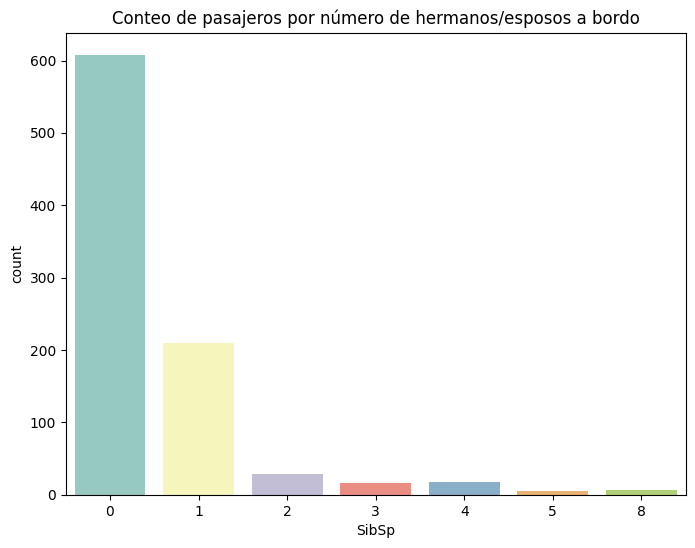

In [24]:
#  17: Conteo de pasajeros por número de hermanos/esposos a bordo (SibSp)
plt.figure(figsize=(8,6))
sns.countplot(x='SibSp', data=df, palette='Set3')
plt.title('Conteo de pasajeros por número de hermanos/esposos a bordo')
plt.show()

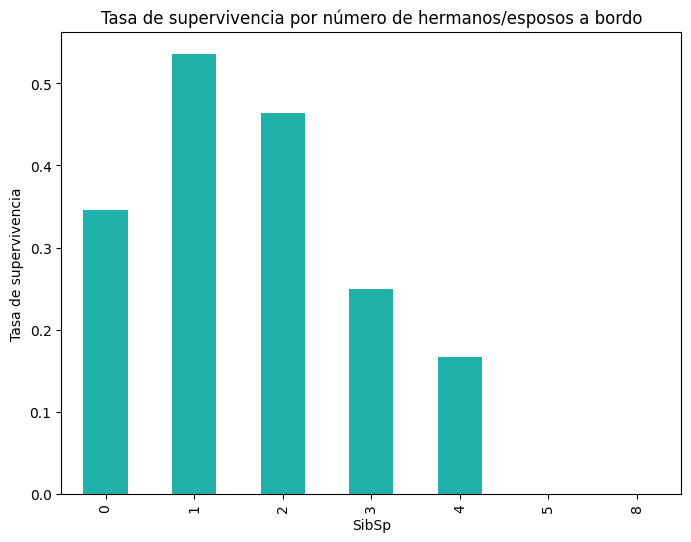

In [25]:
#  18: Tasa de supervivencia basada en SibSp
sibsp_survival = df.groupby('SibSp')['Survived'].mean()
plt.figure(figsize=(8,6))
sibsp_survival.plot(kind='bar', color='lightseagreen')
plt.title('Tasa de supervivencia por número de hermanos/esposos a bordo')
plt.ylabel('Tasa de supervivencia')
plt.show()

In [26]:
#  19: Porcentaje de supervivencia para cada valor de SibSp
percent_survival = df.groupby('SibSp')['Survived'].mean() * 100
percent_survival

SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64

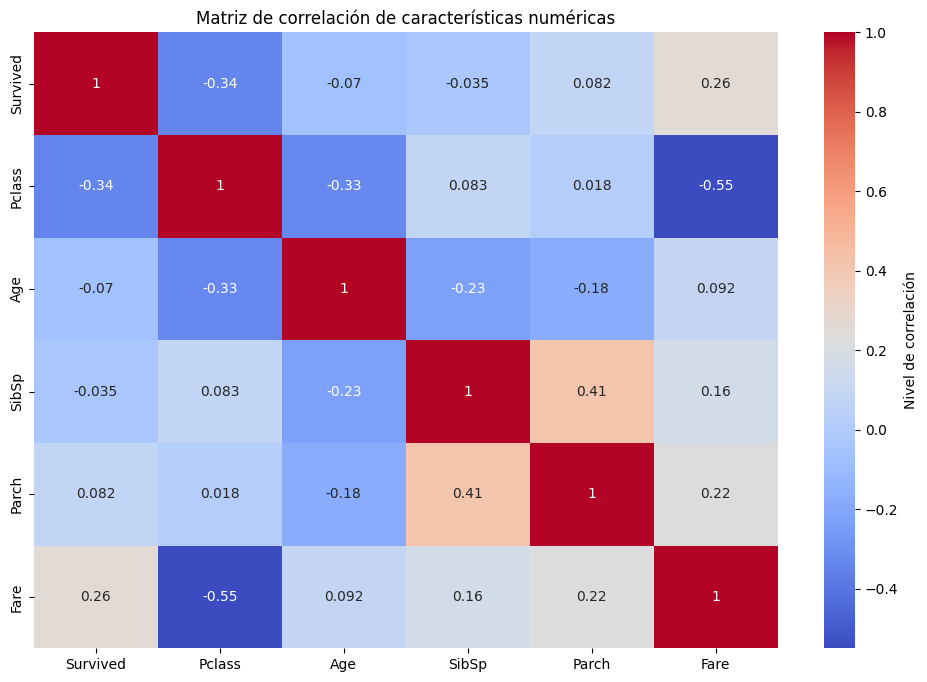

In [27]:
#  20: Mapa de calor (heatmap) de la matriz de correlación de características numéricas
plt.figure(figsize=(12,8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, cmap='coolwarm', cbar_kws={'label': 'Nivel de correlación'})
plt.title('Matriz de correlación de características numéricas')
plt.show()